**LAB 05 : Logistic Regression using TensorFlow**

**Aim**

To implement Logistic Regression using TensorFlow for binary classification and evaluate model performance with visualization.

**Theory**

What is Logistic Regression?

Logistic Regression is used for binary classification problems.

It uses the Sigmoid Function:

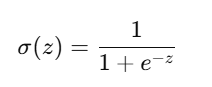

Output range:

0 to 1


If output > 0.5 → Class 1
If output < 0.5 → Class 0

**Dataset Used**

We use inbuilt dataset:

Breast Cancer Wisconsin Dataset

Features: 30

Classes:

0 = Malignant

1 = Benign

**Software Requirements**

Google Colab

Python 3.x

TensorFlow 2.19

**Algorithm**

Import libraries

Load inbuilt dataset

Split dataset

Normalize features

Build Logistic Regression model

Compile with binary crossentropy

Train model

Evaluate accuracy

Visualize results

TensorFlow Version: 2.19.0
Dataset Shape: (569, 30)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9558 - loss: 0.1395  
Test Loss: 0.13449452817440033
Test Accuracy: 0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


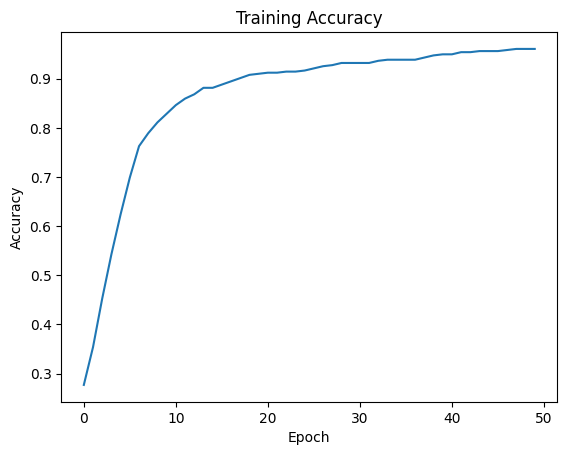

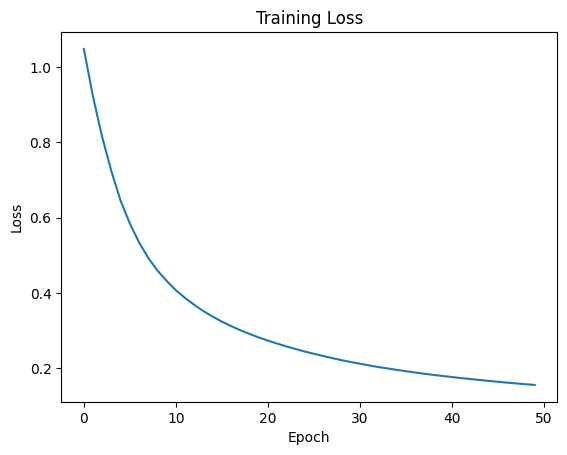

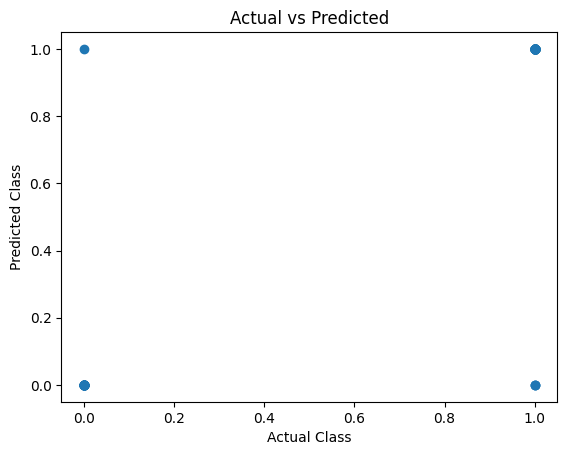

In [ ]:
# ==========================================
# LOGISTIC REGRESSION USING TENSORFLOW
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow Version:", tf.__version__)

# Step 1: Load Dataset
data = load_breast_cancer()
X = data.data
Y = data.target

print("Dataset Shape:", X.shape)

# Step 2: Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Step 3: Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Build Logistic Regression Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(30,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Step 5: Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train
history = model.fit(X_train, Y_train, epochs=50, verbose=0)

# Step 7: Evaluate
loss, accuracy = model.evaluate(X_test, Y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Step 8: Predictions
predictions = model.predict(X_test)

# Convert probabilities to class labels
predicted_classes = (predictions > 0.5).astype(int)

# ============================
# VISUALIZATION SECTION
# ============================

# 1️⃣ Accuracy Curve
plt.figure()
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 2️⃣ Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 3️⃣ Actual vs Predicted Comparison
plt.figure()
plt.scatter(Y_test, predicted_classes)
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("Actual vs Predicted")
plt.show()
